Study ripple-spindle coupling wrt NR ISR

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import xarray as xr
import pandas as pd
import statsmodels.api as sm
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [4]:
def _HpcPfcCoupl(session,duration=1200):
    # get ripple-delta-spindle coupling probability as (event, phase, isr, binomial) XArray

    R = rg.data.Regions(session,states='sws',events='InfraSlowRhythm/infraslowaval',load_spikes=False)

    # intervals of sleep nREM in phases, with maximal duration
    phases = [s for s in list(R.phases) if 'sleep' in s]
    phase_intervals = [fma.general.consolidateIntervals(R.eventIntervals([[p],['sws']]),duration=duration) for p in phases]
    phases.append('baseline')
    phase_intervals.append(fma.general.consolidateIntervals(R.eventIntervals([[phases[0]],['sws']]),duration=-duration))

    # load events
    peak_time = {}
    for name in ['ripples','deltaWaves','spindles']:
        try:
            ev, _ = fma.data.loadEvents(session,name)
            peak_time[name] = ev[name]['col1'] if 'col1' in ev[name] else ev[name]['peaks']
        except:
            peak_time[name] = np.nan # TEST isCoupled
    names = ['ripples','spindles','deltaWaves','deltasr','deltass']

    is_isr = {}
    phase_ind = {}
    for i, n in enumerate(names[:3]):
        _, is_isr[n] = fma.general.restrict(peak_time[n],R.eventIntervals('slownr'),s_ind=True)
        phase_ind[n] = np.full(peak_time[n].shape,np.nan)
        for j, p in enumerate(phases):
            _, is_phase = fma.general.restrict(peak_time[n],phase_intervals[j],s_ind=True)
            phase_ind[n][is_phase] = j

    # coupling
    is_coupled = {}
    is_coupled['ripples'], is_coupled['deltasr'] = isru.isCoupled(peak_time['ripples'],peak_time['deltaWaves'],[0.05,0.25]) # [0.05,0.25]
    is_coupled['deltass'], is_coupled['spindles'] = isru.isCoupled(peak_time['deltaWaves'],peak_time['spindles'],[0.1,1.3]) # [0.1,1.3]
    is_coupled['deltaWaves'] = is_coupled['deltasr'] & is_coupled['deltass']

    # find events in ISR and coupling percentages
    event_names = ['ripples','spindles','deltaWaves','deltaWaves','deltaWaves'] # keep intervals of deltas to compute deltasr and deltass
    perc = np.full((len(names)+1,len(phases),2,3),np.nan) # 1st dim is: ripples, spindles, deltas, deltasr, deltass, duration
    for j, p in enumerate(phases):
        for i, n in enumerate(names):
            for k in [False,True]: # k = 0: ISR, k = 1: nISR
                perc[i,j,int(k),0] = is_coupled[n][(k ^ is_isr[event_names[i]]) & (phase_ind[event_names[i]] == j)].sum()
                perc[i,j,int(k),1] = is_coupled[n][(k ^ is_isr[event_names[i]]) & (phase_ind[event_names[i]] == j)].size
                #perc[i,j,k,2] = perc[i,j,k,0] / perc[i,j,k,1] # DEPRECATED?
        # duration of every recording phase
        perc[-1,j,0,0] = np.diff(fma.general.intersectIntervals((phase_intervals[j],R.eventIntervals('slownr')))).sum()
        perc[-1,j,1,0] = np.diff(fma.general.subtractIntervals(phase_intervals[j],R.eventIntervals('slownr'))).sum()
    with np.errstate(divide='ignore',invalid='ignore'):
        perc[:-1,:,:,2] = perc[:-1,:,:,0] / perc[:-1,:,:,1]

    xdata = xr.DataArray(perc,dims=('event','phase','isr','binomial'),coords={'event': names+['duration'], 'phase': [f'sleep{i+1}'for i in range(len(phases)-1)]+['baseline'], 'isr': [True,False], 'binomial': ['x','n','p']})
    xdata.attrs['sleep2'] = len(phases) > 1 and phases[1] != 'nsleep'  and phases[1] != 'baseline'

    return xdata

In [5]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][5]
print(f'session: {session}')
xdata = _HpcPfcCoupl(session)

session: /mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml


run batch

In [6]:
duration = 1200 # s
data = fma.data.runBatch(batch_file,_HpcPfcCoupl,kwargs={'duration': duration},parallel=True)
sleep_data = [d.sel(phase=['sleep1','baseline','sleep2']) for d in data if d is not None and d.attrs['sleep2']]
data_cat = xr.concat(sleep_data,dim='event')
ph = data_cat['phase'].values


Starting Batch, 2026-06-24 18:25:04.248928 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
too many indices for array: array is 0-dimensional, but 2 were indexed
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
too many indices for array: array is 0-dimensional, but 2 were indexed
Traceback:
Error in session /mnt/hubel-data-148/b

1. ripple and spindle rates

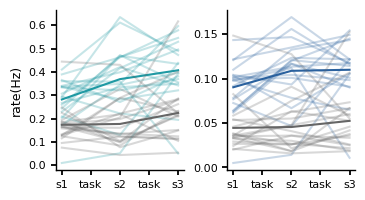

In [6]:
# see all data OLD
fig, axs = fma.plotting.makeFigure('',[1,2],[9,5])
axs[0].plot(data_cat.sel(event='ripples',isr=True,binomial=1).T / duration,color=isru.paperColors(9,'40'))
axs[0].plot(data_cat.sel(event='ripples',isr=True,binomial=1).mean('event') / duration,color=isru.paperColors(9))
axs[0].plot(data_cat.sel(event='ripples',isr=False,binomial=1).T / duration,color='#66666640')
axs[0].plot(data_cat.sel(event='ripples',isr=False,binomial=1).mean('event') / duration,color="#666666")
axs[0].set_ylabel('rate(Hz)'), axs[0].set_xticks([0,0.5,1,1.5,2]), axs[0].set_xticklabels(['s1','task','s2','task','s3'])
axs[1].plot(data_cat.sel(event='spindles',isr=True,binomial=1).T / duration,color=isru.paperColors(10,'40'))
axs[1].plot(data_cat.sel(event='spindles',isr=True,binomial=1).mean('event') / duration,color=isru.paperColors(10))
axs[1].plot(data_cat.sel(event='spindles',isr=False,binomial=1).T / duration,color='#66666640')
axs[1].plot(data_cat.sel(event='spindles',isr=False,binomial=1).mean('event') / duration,color="#666666")
axs[1].set_xticks([0,0.5,1,1.5,2]), axs[1].set_xticklabels(['s1','task','s2','task','s3']);

In [ ]:
# model for difference of rate + time
event = 'ripples'
n = data_cat.sel(event=event,isr=True,binomial=1,phase=ph)
N, M = n.shape
dfISR = pd.DataFrame({
    "events": n.values.flatten(),
    "duration": np.full((n.size),duration),
    "time": np.tile(np.arange(M),N),
    "experiment": np.repeat(np.arange(N),M),
    "isr": 1})
n = data_cat.sel(event=event,isr=False,binomial=1,phase=ph)
dfnISR = pd.DataFrame({
    "events": n.values.flatten(),
    "duration": np.full((n.size),duration),
    "time": np.tile(np.arange(M), N),
    "experiment": np.repeat(np.arange(N), M),
    "isr": 0})
df = pd.concat([dfnISR,dfISR],ignore_index=True)
# Poisson GEE with duration as offset
model = sm.GEE.from_formula(
    "events ~ isr * time",
    groups="experiment",
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["duration"]),
    cov_struct=sm.cov_struct.Exchangeable())
result = model.fit(cov_type="bias_reduced")
print(result.summary())

```
                               GEE Regression Results (ripples)                    
===================================================================================
Dep. Variable:                      events   No. Observations:                   76
Model:                                 GEE   No. clusters:                       19
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                   4
Family:                            Poisson   Mean cluster size:                 4.0
Dependence structure:         Exchangeable   Num. iterations:                     2
Date:                     Fri, 20 Feb 2026   Scale:                           1.000
Covariance type:              bias_reduced   Time:                         15:13:40
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.7556      0.107    -16.464      0.000      -1.965      -1.547  ---> rate(isr=0,t=0) != 0
isr              0.4887      0.176      2.780      0.005       0.144       0.833  ---> rate(isr=1,t=0) != rate(isr=0,t=0)
time             0.0218      0.123      0.177      0.859      -0.220       0.264  ---> rate(isr=0,t=1) != rate(isr=0,t=0) is n.s.
isr:time         0.2478      0.203      1.220      0.222      -0.150       0.646  ---> difference between isr 0 and 1 is constant
==============================================================================
Skew:                          0.0460   Kurtosis:                       1.5466
Centered skew:                 0.1048   Centered kurtosis:              1.4265
==============================================================================

                               GEE Regression Results (spindles)                   
===================================================================================
Dep. Variable:                      events   No. Observations:                   76
Model:                                 GEE   No. clusters:                       19
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                   4
Family:                            Poisson   Mean cluster size:                 4.0
Dependence structure:         Exchangeable   Num. iterations:                     2
Date:                     Fri, 20 Feb 2026   Scale:                           1.000
Covariance type:              bias_reduced   Time:                         15:14:45
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.1129      0.155    -20.056      0.000      -3.417      -2.809  ---> rate(isr=0,t=0) != 0
isr              0.7073      0.223      3.178      0.001       0.271       1.144  ---> rate(isr=1,t=0) != rate(isr=0,t=0)
time             0.0224      0.124      0.181      0.857      -0.221       0.266  ---> rate(isr=0,t=1) != rate(isr=0,t=0) is n.s.
isr:time         0.1642      0.180      0.912      0.362      -0.189       0.517  ---> difference between isr 0 and 1 is constant
==============================================================================
Skew:                          0.2136   Kurtosis:                       2.3309
Centered skew:                 0.0522   Centered kurtosis:              2.6609
==============================================================================
```

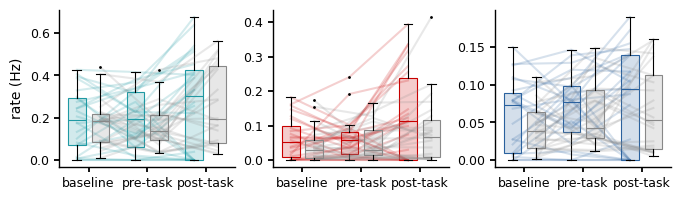

In [13]:
# ripple and spindle rate
fig, axs = fma.plotting.makeFigure('',[1,3],size=[17,5])
alpha = '30'
x = np.linspace(-1,1,3)
dx = 0.2
c_ind = {True: ['ripples','deltas','spindles'], False: ['shuffle']*3}
for i, name in enumerate(['ripples','deltaWaves','spindles']):
    for j in [True,False]:
        axs[i].plot(x+dx*(-1)**j,data_cat.sel(event=name,isr=j,binomial='n',phase=ph).T / duration,color=isru.paperColors(c_ind[j][i],alpha))
        fma.plotting.boxPlot(data_cat.sel(event=name,isr=j,binomial='n',phase=ph).T / duration,x=x+dx*(-1)**j,color=isru.paperColors(c_ind[j][i]),ax=axs[i])
        axs[i].set(xlim=[-1-2.5*dx,1+2.5*dx],xticks=x,xticklabels=['baseline','pre-task','post-task'])
axs[0].set_ylabel('rate (Hz)');
do_save and fma.plotting.saveFigure(fig,froot/'oscill_rates',['png','svg'])

3. coupling probability

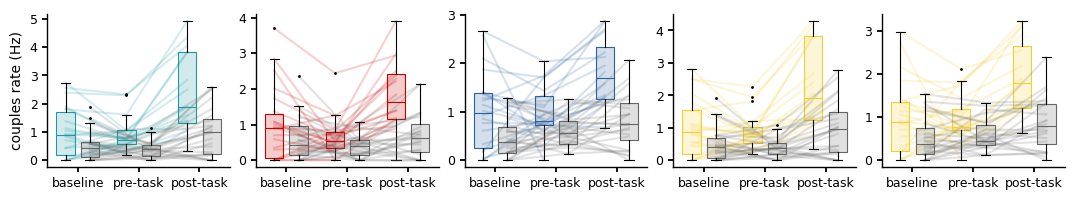

In [25]:
# SUPPLEMENTARY WITH ALL 5
fig, axs = fma.plotting.makeFigure('',[1,5],[27,5])
alpha = '30'
x = np.linspace(-1,1,3)
dx = 0.2
names = ['ripples','deltas','spindles','deltasr','deltass']
c_ind = {True: names, False: ['shuffle']*5}
for i, n in enumerate(names):
    this_data = data_cat.sel(event=n,binomial='x',phase=ph) / data_cat.sel(event='duration',binomial='x',phase=ph).values # rate of coupled events
    this_data = this_data / this_data.sel(phase='sleep1',isr=True).mean() # normalize w.r.t. baseline
    for j in [True,False]:
        axs[i].plot(x+dx*(-1)**j,this_data.sel(isr=j).T,color=isru.paperColors(c_ind[j][i],alpha))
        fma.plotting.boxPlot(this_data.sel(isr=j).values,x=x+dx*(-1)**j,color=isru.paperColors(c_ind[j][i]),ax=axs[i])
        #fma.plotting.pBar([[0,1,0],[0,2,0],[1,3,0],[2,3,0]],x=[-dx,dx,1-dx,1+dx],ax=axs[0],draw=[False,True,False,False])
axs[0].set(ylabel='couples rate (Hz)')
fma.plotting.setProp(axs,xticks=x,xticklabels=['baseline','pre-task','post-task'],xlim=[-1-2.5*dx,1+2.5*dx])

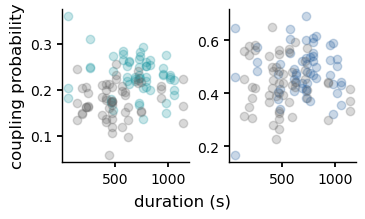

In [10]:
# check if duration is linked with coupling rate
fig, axs = fma.plotting.makeFigure('',[1,2],[9,5.5])
axs[0].scatter((data_cat.sel(event='duration',isr=True,binomial=0)).values.ravel(),(data_cat.sel(event='ripples',isr=True,binomial=0)/data_cat.sel(event='ripples',isr=True,binomial=1)).values.ravel(),color=isru.paperColors(9,'40'))
axs[0].scatter((data_cat.sel(event='duration',isr=False,binomial=0)).values.ravel(),(data_cat.sel(event='ripples',isr=False,binomial=0)/data_cat.sel(event='ripples',isr=False,binomial=1)).values.ravel(),color='#66666640')
axs[0].set_ylabel('coupling probability')
axs[1].scatter((data_cat.sel(event='duration',isr=True,binomial=0)).values.ravel(),(data_cat.sel(event='spindles',isr=True,binomial=0)/data_cat.sel(event='spindles',isr=True,binomial=1)).values.ravel(),color=isru.paperColors(10,'40'))
axs[1].scatter((data_cat.sel(event='duration',isr=False,binomial=0)).values.ravel(),(data_cat.sel(event='spindles',isr=False,binomial=0)/data_cat.sel(event='spindles',isr=False,binomial=1)).values.ravel(),color='#66666640')
fig.supxlabel('duration (s)');

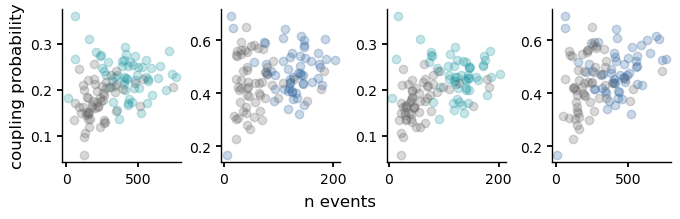

In [11]:
# check if number of events is linked with coupling rate of same / different type
fig, axs = fma.plotting.makeFigure('',[1,4],[17,5.5])
# same type
axs[0].scatter((data_cat.sel(event='ripples',isr=True,binomial=1)).values.ravel(),(data_cat.sel(event='ripples',isr=True,binomial=0)/data_cat.sel(event='ripples',isr=True,binomial=1)).values.ravel(),color=isru.paperColors(9,'40'))
axs[0].scatter((data_cat.sel(event='ripples',isr=False,binomial=1)).values.ravel(),(data_cat.sel(event='ripples',isr=False,binomial=0)/data_cat.sel(event='ripples',isr=False,binomial=1)).values.ravel(),color='#66666640')
axs[0].set_ylabel('coupling probability')
axs[1].scatter((data_cat.sel(event='spindles',isr=True,binomial=1)).values.ravel(),(data_cat.sel(event='spindles',isr=True,binomial=0)/data_cat.sel(event='spindles',isr=True,binomial=1)).values.ravel(),color=isru.paperColors(10,'40'))
axs[1].scatter((data_cat.sel(event='spindles',isr=False,binomial=1)).values.ravel(),(data_cat.sel(event='spindles',isr=False,binomial=0)/data_cat.sel(event='spindles',isr=False,binomial=1)).values.ravel(),color='#66666640')
# different type
axs[2].scatter((data_cat.sel(event='spindles',isr=True,binomial=1)).values.ravel(),(data_cat.sel(event='ripples',isr=True,binomial=0)/data_cat.sel(event='ripples',isr=True,binomial=1)).values.ravel(),color=isru.paperColors(9,'40'))
axs[2].scatter((data_cat.sel(event='spindles',isr=False,binomial=1)).values.ravel(),(data_cat.sel(event='ripples',isr=False,binomial=0)/data_cat.sel(event='ripples',isr=False,binomial=1)).values.ravel(),color='#66666640')
axs[3].scatter((data_cat.sel(event='ripples',isr=True,binomial=1)).values.ravel(),(data_cat.sel(event='spindles',isr=True,binomial=0)/data_cat.sel(event='spindles',isr=True,binomial=1)).values.ravel(),color=isru.paperColors(10,'40'))
axs[3].scatter((data_cat.sel(event='ripples',isr=False,binomial=1)).values.ravel(),(data_cat.sel(event='spindles',isr=False,binomial=0)/data_cat.sel(event='spindles',isr=False,binomial=1)).values.ravel(),color='#66666640')
fig.supxlabel('n events');

In [ ]:
# model for difference of coupling probability + time
event = 'spindles'
ph=['sleepm','sleepn']
Y = data_cat.sel(event=event,isr=True,binomial=0,phase=ph)
n = data_cat.sel(event=event,isr=True,binomial=1,phase=ph)
N, M = Y.shape
dfISR = pd.DataFrame({'successes': Y.values.flatten(),
                      'trials': n.values.flatten(),
                      'time': np.tile(np.arange(M),N),
                      'experiment': np.repeat(np.arange(N),M),
                      'isr': 1})
dfnISR = pd.DataFrame({'successes': data_cat.sel(event=event,isr=False,binomial=0,phase=ph).values.flatten(),
                       'trials': data_cat.sel(event=event,isr=False,binomial=1,phase=ph).values.flatten(),
                       'time': np.tile(np.arange(M),N),
                       'experiment': np.repeat(np.arange(N),M),
                       'isr': 0})
df = pd.concat([dfnISR,dfISR], ignore_index=True)
df["failures"] = df["trials"] - df["successes"]
model = sm.GEE.from_formula(
    "successes + failures ~ isr * time",
    groups="experiment",
    data=df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable())
result = model.fit(cov_type="bias_reduced")
print(result.summary())

```
                                 GEE Regression Results (ripples)                       
========================================================================================
Dep. Variable:        ['successes', 'failures']   No. Observations:                   76
Model:                                      GEE   No. clusters:                       19
Method:                             Generalized   Min. cluster size:                   4
                           Estimating Equations   Max. cluster size:                   4
Family:                                Binomial   Mean cluster size:                 4.0
Dependence structure:              Exchangeable   Num. iterations:                     2
Date:                          Fri, 20 Feb 2026   Scale:                           1.000
Covariance type:                   bias_reduced   Time:                         11:12:03
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4857      0.057    -25.919      0.000      -1.598      -1.373  ---> p(isr=0,t=0) = 0.184 = p0
isr            0.2140      0.084      2.538      0.011       0.049       0.379  ---> p(isr=1,t=0) = 1.24 * p0
time          -0.1679      0.083     -2.018      0.044      -0.331      -0.005  ---> p(isr=0,t=1) = 0.845 * p0
isr:time       0.2667      0.128      2.086      0.037       0.016       0.517  ---> p(isr=1,t=1) = isr + isr:time = 1.10 * p(isr=1,t=0)
==============================================================================
Skew:                         -0.5271   Kurtosis:                       0.9223
Centered skew:                -0.4138   Centered kurtosis:              1.1988
==============================================================================

                                 GEE Regression Results (spindles)                      
========================================================================================
Dep. Variable:        ['successes', 'failures']   No. Observations:                   76
Model:                                      GEE   No. clusters:                       19
Method:                             Generalized   Min. cluster size:                   4
                           Estimating Equations   Max. cluster size:                   4
Family:                                Binomial   Mean cluster size:                 4.0
Dependence structure:              Exchangeable   Num. iterations:                     2
Date:                          Fri, 20 Feb 2026   Scale:                           1.000
Covariance type:                   bias_reduced   Time:                         11:29:39
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2260      0.085     -2.652      0.008      -0.393      -0.059  ---> p(isr=0,t=0) = 0.444 = p0
isr           -0.0323      0.122     -0.265      0.791      -0.270       0.206  ---> p(isr=1,t=0) = 0.968 * p0 (n.s.)
time          -0.1639      0.134     -1.220      0.223      -0.427       0.099  ---> p(isr=0,t=1) = 0.849 * p0 (n.s.)
isr:time       0.3910      0.179      2.183      0.029       0.040       0.742  ---> p(isr=1,t=1) = isr + isr:time = 1.25 * p(isr=1,t=0): Δ(ISR-nISR) increases!
==============================================================================
Skew:                          0.2112   Kurtosis:                       0.3328
Centered skew:                 0.1336   Centered kurtosis:             -0.0170
==============================================================================
```

other tested model strategies

In [ ]:
# model for the effect of time at every sleep stage + duration
event = 'ripples'
do_isr = True
Y = data_cat.sel(event=event,isr=do_isr,binomial=0)
n = data_cat.sel(event=event,isr=do_isr,binomial=1)
duration = data_cat.sel(event='duration',isr=do_isr,binomial=0)
N, M = Y.shape
df = pd.DataFrame({'successes': Y.values.flatten(),
                   'trials': n.values.flatten(),
                   'time': np.tile(np.arange(M),N),
                   'experiment': np.repeat(np.arange(N), M),
                   'duration': duration.values.flatten()})
df["failures"] = df["trials"] - df["successes"] # preserves binomial likelihood
df["time"] = df["time"].astype("category")
model = sm.GEE.from_formula(
    "successes + failures ~ C(time) + duration",
    groups="experiment",
    data=df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable())
result = model.fit(cov_type="bias_reduced")
print(result.summary())

In [ ]:
# two time points regression + n spindles
# note: assuming indepence between ripples and spindles generation, number of ripples needs not be included to predict ripples success rate
event = 'ripples'
other = ['ripples','spindles']
other.remove(event)
do_isr = True
Y = data_cat.sel(event=event,isr=do_isr,binomial=0,phase=['sleepm','sleepn'])
n = data_cat.sel(event=event,isr=do_isr,binomial=1,phase=['sleepm','sleepn'])
o = data_cat.sel(event=other[0],isr=do_isr,binomial=1,phase=['sleepm','sleepn'])
N, M = Y.shape
df = pd.DataFrame({'successes': Y.values.flatten(),
                   'trials': n.values.flatten(),
                   'other': o.values.flatten(),
                   'time': np.tile(np.arange(M),N),
                   'experiment': np.repeat(np.arange(N), M)})
df["failures"] = df["trials"] - df["successes"] # preserves binomial likelihood
model = sm.GEE.from_formula(
    'successes + failures ~ time + other',
    groups='experiment',
    data=df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable())
result = model.fit(cov_type="bias_reduced")
print(result.summary())